# Search and download raster data from STAC APIs

Use STAC data sources to generate a demonstration raster dataset for point-eo.

The original point-eo demo data contains 9 Sentinel-2 bands stacked in one GeoTIFF.

Here we use Copernicus Data Space STAC to retrieve Landsat bi-monthly and Sentinel-1 monthly mosaics, and compute the median/mean over the summer period of 2018.

Additionally, we retrieve some layers from CSC Paituli STAC, namely DEM, canopy cover, and vegetation height. The timestamps of these layers vary.

The resulting xarray.Datasets are stored as individual GeoTIFF files.

Finally, we can merge the lazy data cubes into a single dataset and store that as well. The lazy cube can also be used to directly sample training points without downloading the complete area of interest.

    mamba install odc-stac pystac-client boto3

In [1]:
import os

import numpy as np
import yaml
from pystac_client import Client
import rasterio
import rioxarray
import xarray as xr

from odc.stac import configure_rio, stac_load, configure_s3_access
from odc.geo.geobox import GeoBox
from odc.geo.geom import Geometry
from IPython.display import display

import dask.distributed
from dask.distributed import Lock
from shapely.geometry import box
import dask
import warnings



## Setup

In [2]:
# Set to False if you just want to get lazy variables
writeoutputs = False

output_path = '../data/stac_sources'
os.makedirs(output_path, exist_ok=True)

# Generate search area from existing example dataset
refraster = '../data/s2_2018_lataseno.tif'
resolution = 10  # Use native Landsat 30m resolution for all data sources

# Tile size for dask processing
blocksize = 256

# Settings for GeoTIFF writing
writeargs = {
    'driver': 'GTiff',
    'compress': 'LZW',
    'tiled': True,
    'windowed': True,
    'blockxsize': blocksize,
    'blockysize': blocksize,
    'BIGTIFF': 'YES',
    'num_threads': 'all_cpus',
}

### Configure access to Copernicus Data Space S3 storage

The STAC Catalog API can be accessed anonymously, but data access requires an account with properly configured rights.

Here we assume that you have configured the credentials in the default AWS configuration (~/.aws/credentials) as a profile called 'cdse'.

In [3]:
# Use S3 credentials from named profile in ~/.aws/credentials
aws_profile = 'cdse'

# Configuration for Copernicus Data Space access
os.environ['AWS_PROFILE'] = aws_profile
os.environ['AWS_S3_ENDPOINT'] = "eodata.dataspace.copernicus.eu"
os.environ['AWS_HTTPS'] = "YES"
os.environ['AWS_VIRTUAL_HOSTING'] = "FALSE"
os.environ['GDAL_HTTP_UNSAFESSL'] = "YES"
os.environ['GDAL_HTTP_TCP_KEEPALIVE'] = "YES"

# Relax default retry options slightly
os.environ["GDAL_HTTP_MAX_RETRY"] = "10"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "3"

o = configure_s3_access(profile=aws_profile)
configure_rio(
    aws={
        "endpoint_url": os.environ['AWS_S3_ENDPOINT'],
        "aws_access_key_id": o.access_key,
        "aws_secret_access_key": o.secret_key,
        "region_name": "default",
    },
    AWS_VIRTUAL_HOSTING=False
)

### Start a local Dask cluster for parallel downloads

Adapt settings to your available resources.

In [4]:
# Use dask for parallel data downloads and processing
cluster = dask.distributed.LocalCluster(
    n_workers=3,  # Number of worker processes
    threads_per_worker=1,  # Threads per worker
    memory_limit="500M"  # Limit memory per worker
)
dask_client = dask.distributed.Client(cluster)
dask_client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 3
Total threads: 3,Total memory: 1.40 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44219,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46451,Total threads: 1
Dashboard: http://127.0.0.1:39763/status,Memory: 476.84 MiB
Nanny: tcp://127.0.0.1:34513,


In [5]:

def silence_warnings():
    warnings.filterwarnings(
        "ignore",
        message="All-NaN slice encountered", 
        category=RuntimeWarning
    )

dask_client.run(silence_warnings)

{'tcp://127.0.0.1:42651': None,
 'tcp://127.0.0.1:46451': None,
 'tcp://127.0.0.1:46829': None}

### Configure STAC endpoints

In [6]:
# CDSE STAC Catalog
cdse_catalog = Client.open("https://stac.dataspace.copernicus.eu/v1")
cdse_catalog.add_conforms_to("ITEM_SEARCH")

# Paituli STAC catalog
paituli_catalog = Client.open('https://paituli.csc.fi/geoserver/ogc/stac/v1')
paituli_catalog.add_conforms_to("ITEM_SEARCH")

Some collections may have implemented `proj:transform` in an order that is not supported by odc-stac. Define helper functions to fix this issue.

In [7]:
def reorder_transform(gdal_transform):
    """
    https://nrcan.github.io/cloud-optimized-geospatial/reorder-transform-example/
    
    Reorders the GDAL GeoTransform (6-element tuple) into the 9-element format
    that is compatible with proj:transform.
    """
    return [
        gdal_transform[1], gdal_transform[2], gdal_transform[0],
        gdal_transform[4], gdal_transform[5], gdal_transform[3],
        0, 0, 1
    ]


def fix_gdal_transform(items):
    """
    Convert proj:transform to rasterio ordering for each item/asset.
    """
    for it in items:
        for a in it.assets:
            it.assets[a].extra_fields['proj:transform'] = reorder_transform(
                it.assets[a].extra_fields['proj:transform']
            )
    return items

### Define area of interest for processing

The data cube grid (extent, resolution, and CRS) is defined here by copying properties from an existing raster.

The same AOI is used for both data discovery via STAC search and for generation of xarray datasets.

In [48]:
# Generate grid, get AOI from existing raster dataset
src = rasterio.open(refraster)
AOI = GeoBox.from_geopolygon(
    Geometry(box(*src.bounds), f'epsg:{src.crs.to_epsg()}'),
    resolution
)

# Fix bounding box and chunking for all data cubes
stac_load_default_args = {
    'resampling': 'nearest',
    'chunks': {'time': -1, 'x': blocksize, 'y': blocksize},  # Important!
    'geobox': AOI,  # Defines grid: bbox and resolution
}

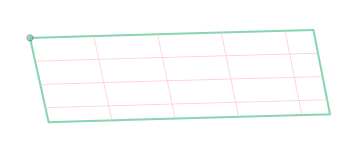

In [49]:
AOI

## CDSE STAC

### Landsat bimonthly mosaics

Start by searching the STAC catalog for available assets.

In [50]:
lc_collection = 'opengeohub-landsat-bimonthly-mosaic-v1.0.1'

startdate = "2018-05-01"
enddate = "2018-09-30"

# Configure collection for odc-stac, ensures correct data types
landsat_cfg_str = f"""{lc_collection}:
  assets:
    "*":
      data_type: uint8
      nodata: 255
      unit: "1"
"""

timespan = f"{startdate}/{enddate}"

# Search for STAC items
lcm_query = cdse_catalog.search(
    collections=[lc_collection],
    datetime=timespan,
    bbox=AOI.boundingbox.to_crs('epsg:4326').bbox,
)

# For some CDSE collections, proj:transform has an order incompatible with odc-stac
lcm_items = fix_gdal_transform(list(lcm_query.items()))

Check the available bands and assets

In [51]:
display(lcm_items[0].assets)
display(lcm_items[0].assets['B02'].to_dict())

{'B01': <Asset href=s3://eodata/Global-Mosaics/Landsat/OLM_SWA_ARD2/v1/2018/09/01/Landsat_mosaic_2018_09-10_68N022E_V1.0.1/B01_2018.tif>,
 'B02': <Asset href=s3://eodata/Global-Mosaics/Landsat/OLM_SWA_ARD2/v1/2018/09/01/Landsat_mosaic_2018_09-10_68N022E_V1.0.1/B02_2018.tif>,
 'B03': <Asset href=s3://eodata/Global-Mosaics/Landsat/OLM_SWA_ARD2/v1/2018/09/01/Landsat_mosaic_2018_09-10_68N022E_V1.0.1/B03_2018.tif>,
 'B04': <Asset href=s3://eodata/Global-Mosaics/Landsat/OLM_SWA_ARD2/v1/2018/09/01/Landsat_mosaic_2018_09-10_68N022E_V1.0.1/B04_2018.tif>,
 'B05': <Asset href=s3://eodata/Global-Mosaics/Landsat/OLM_SWA_ARD2/v1/2018/09/01/Landsat_mosaic_2018_09-10_68N022E_V1.0.1/B05_2018.tif>,
 'B06': <Asset href=s3://eodata/Global-Mosaics/Landsat/OLM_SWA_ARD2/v1/2018/09/01/Landsat_mosaic_2018_09-10_68N022E_V1.0.1/B06_2018.tif>,
 'B07': <Asset href=s3://eodata/Global-Mosaics/Landsat/OLM_SWA_ARD2/v1/2018/09/01/Landsat_mosaic_2018_09-10_68N022E_V1.0.1/B07_2018.tif>,
 'clear_sky_mask': <Asset href=s3:

{'href': 's3://eodata/Global-Mosaics/Landsat/OLM_SWA_ARD2/v1/2018/09/01/Landsat_mosaic_2018_09-10_68N022E_V1.0.1/B02_2018.tif',
 'type': 'image/tiff; application=geotiff; profile=cloud-optimized',
 'title': 'Band 2',
 'file:size': 5488792,
 'proj:shape': [4000, 4000],
 'proj:transform': [0.00025, 0.0, 22.0, 0.0, -0.00025, 69.0, 0, 0, 1],
 'bands': [{'name': 'B02',
   'description': 'Green',
   'eo:common_name': 'green',
   'eo:center_wavelength': 0.561,
   'eo:full_width_half_max': 0.057}],
 'auth:refs': ['s3'],
 'data_type': 'uint8',
 'storage:refs': ['cdse-s3', 'creodias-s3'],
 'roles': ['data']}

Create a lazy data cube from the list of STAC items using the [odc-stac](https://odc-stac.readthedocs.io/en/latest/) library and aggregate by computing the median over the given time frame.

In [52]:
landsat_cube = stac_load(
    lcm_items,
    stac_cfg=yaml.safe_load(landsat_cfg_str),
    **stac_load_default_args
)

# Compute masked temporal median
landsat_yearly_median = (
    landsat_cube
    .where(landsat_cube['clear_sky_mask'] == 1)
    .median(dim="time")
)

landsat_yearly_median

<xarray.Dataset> Size: 129MB
Dimensions:         (y: 1812, x: 2222)
Coordinates:
  * y               (y) float64 14kB 7.62e+06 7.62e+06 ... 7.602e+06 7.602e+06
  * x               (x) float64 18kB 2.975e+05 2.975e+05 ... 3.197e+05 3.197e+05
    spatial_ref     int32 4B 25835
Data variables:
    B01             (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B02             (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B03             (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B04             (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B05             (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B06             (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B07             (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    clear_sky_mask  (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>

Save yearly median to disk as a single GeoTIFF. This is the first time the actual data will be retrieved.

In [53]:
if writeoutputs:
    # Fetch data and write to GeoTIFF
    landsat_yearly_median.rio.to_raster(
        os.path.join(
            output_path,
            f'{lc_collection}_{startdate}-{enddate}_median.tif'
        ),
        lock=Lock(),
        **writeargs
    )

Visualize arrays. Note that 'landsat_cube' is still a lazy array, which means that this cell will trigger partial downloads.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..5.9765625].
2026-02-19 13:18:24,692 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 377.30 MiB -- Worker memory limit: 476.84 MiB
2026-02-19 13:18:27,804 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 371.50 MiB -- Worker memory limit: 476.84 MiB
2026-02-19 13:18:33,105 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not 

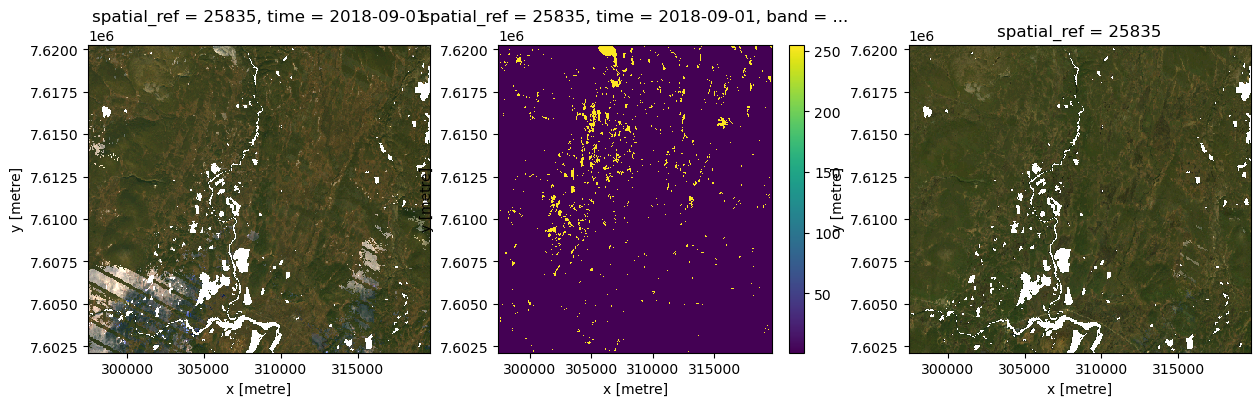

In [ ]:
showsamples = False
if showsamples:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(15, 4))

    # plot only every n'th pixel to save memory
    reduce = 5

    # The third (autumn) composite has cloud artifacts on the lower part of the AOI
    # that are not detected by 'clear_sky_mask'
    aoi_rgb_nomask = (
        landsat_cube[['B03', 'B02', 'B01']]
        .to_dataarray(dim="band")
        .isel(x=slice(None, None, reduce),y=slice(None, None, reduce))
        .sel(time=landsat_cube.time[2])
    )
    (aoi_rgb_nomask / 128 * 3).plot.imshow(rgb="band", ax=ax[0])

    # Show corresponding mask
    mask = (
        landsat_cube[['clear_sky_mask']]
        .to_dataarray(dim="band")
        .isel(x=slice(None, None, reduce),y=slice(None, None, reduce))
        .sel(time=landsat_cube.time[2])
        .squeeze()
    )
    (mask).plot.imshow(ax=ax[1])

    # However, median of the three composites is relatively good
    (landsat_yearly_median[["B03", "B02", "B01"]] / 128 * 3).to_dataarray(
        dim='band'
    ).isel(x=slice(None, None, reduce),y=slice(None, None, reduce)).plot.imshow(rgb="band", ax=ax[2])

### CDSE S2 Global mosaics

Fetch S2 global mosaic data, this dataset contains only 4 bands, 2,3,4, and 8 but has higher native spatial resolution (10m)  than Landsat mosaics (30m)

In [55]:
s2gm_collection = 'sentinel-2-global-mosaics'

startdate = "2018-07-01"
enddate = "2018-07-30"


timespan = f"{startdate}/{enddate}"

# Search for STAC items
s2gm_query = cdse_catalog.search(
    collections=[s2gm_collection],
    datetime=timespan,
    bbox=AOI.boundingbox.to_crs('epsg:4326').bbox,
)

s2gm_items = list(s2gm_query.items())



In [56]:
# Only one time step but two tiles
s2gm_items

[<Item id=Sentinel-2_mosaic_2018_Q3_34WEB_0_0>,
 <Item id=Sentinel-2_mosaic_2018_Q3_34WEA_0_0>]

In [57]:

display(s2gm_items[0].assets)
display(s2gm_items[0].assets['B02'].to_dict())

{'B02': <Asset href=s3://eodata/Global-Mosaics/Sentinel-2/S2MSI_L3__MCQ/2018/07/01/Sentinel-2_mosaic_2018_Q3_34WEB_0_0/B02.tif>,
 'B03': <Asset href=s3://eodata/Global-Mosaics/Sentinel-2/S2MSI_L3__MCQ/2018/07/01/Sentinel-2_mosaic_2018_Q3_34WEB_0_0/B03.tif>,
 'B04': <Asset href=s3://eodata/Global-Mosaics/Sentinel-2/S2MSI_L3__MCQ/2018/07/01/Sentinel-2_mosaic_2018_Q3_34WEB_0_0/B04.tif>,
 'B08': <Asset href=s3://eodata/Global-Mosaics/Sentinel-2/S2MSI_L3__MCQ/2018/07/01/Sentinel-2_mosaic_2018_Q3_34WEB_0_0/B08.tif>,
 'Product': <Asset href=https://download.dataspace.copernicus.eu/odata/v1/Products(54371e02-7eae-4833-87d7-145dd068a0f3)/$value>,
 'userdata': <Asset href=s3://eodata/Global-Mosaics/Sentinel-2/S2MSI_L3__MCQ/2018/07/01/Sentinel-2_mosaic_2018_Q3_34WEB_0_0/userdata.json>,
 'observations': <Asset href=s3://eodata/Global-Mosaics/Sentinel-2/S2MSI_L3__MCQ/2018/07/01/Sentinel-2_mosaic_2018_Q3_34WEB_0_0/observations.tif>}

{'href': 's3://eodata/Global-Mosaics/Sentinel-2/S2MSI_L3__MCQ/2018/07/01/Sentinel-2_mosaic_2018_Q3_34WEB_0_0/B02.tif',
 'type': 'image/tiff; application=geotiff; profile=cloud-optimized',
 'title': 'Blue (band 2)',
 'bands': [{'name': 'B02',
   'description': 'Blue (band 2)',
   'eo:common_name': 'blue',
   'eo:center_wavelength': 0.493,
   'eo:full_width_half_max': 0.267}],
 'alternate': {'https': {'href': 'https://zipper.dataspace.copernicus.eu/odata/v1/Products(54371e02-7eae-4833-87d7-145dd068a0f3)/Nodes(Sentinel-2_mosaic_2018_Q3_34WEB_0_0)/Nodes(B02.tif)/$value',
   'auth:refs': ['oidc'],
   'storage:refs': [],
   'alternate:name': 'HTTPS'}},
 'auth:refs': ['s3'],
 'file:size': 164595928,
 'proj:bbox': [499979.1528208666,
  7597972.238580683,
  604208.8155363329,
  7702121.208634108],
 'storage:refs': ['cdse-s3', 'creodias-s3'],
 'file:local_path': 'Sentinel-2_mosaic_2018_Q3_34WEB_0_0/B02.tif',
 'gsd': 10,
 'nodata': -32768,
 'data_type': 'int16',
 'proj:shape': [10008, 10008],
 'a

In [58]:

s2gm_cube = stac_load(
    s2gm_items,
    **stac_load_default_args
)

# Compute masked temporal median
s2gm_yearly_mean = (
    s2gm_cube
    .mean(dim="time")
)

s2gm_yearly_mean



<xarray.Dataset> Size: 81MB
Dimensions:       (y: 1812, x: 2222)
Coordinates:
  * y             (y) float64 14kB 7.62e+06 7.62e+06 ... 7.602e+06 7.602e+06
  * x             (x) float64 18kB 2.975e+05 2.975e+05 ... 3.197e+05 3.197e+05
    spatial_ref   int32 4B 25835
Data variables:
    B02           (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B03           (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B04           (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B08           (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    observations  (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>

In [59]:

if writeoutputs:
    # Fetch data and write to GeoTIFF
    s2gm_yearly_mean.rio.to_raster(
        os.path.join(
            output_path,
            f'{s2gm_collection}_{startdate}-{enddate}_mean.tif'
        ),
        lock=Lock(),
        **writeargs
    )

### CDSE Sentinel-1 global mosaics

Next fetch radar data. The mosaics are monthly and no additional masking is required. In this case, there are extra assets that are not needed, thus use only 'VV' and 'VH' bands.

In [60]:
# S1 global mosaics from CDSE
s1_collection = 'sentinel-1-global-mosaics'
s1gm_query = cdse_catalog.search(
    collections=[s1_collection],
    datetime=timespan,
    bbox=AOI.boundingbox.to_crs('epsg:4326').bbox,
)

s1gm_items = list(s1gm_query.items())

display(s1gm_items[0])
display(s1gm_items[0].assets)

# Create lazy data cube
s1gm_cube = stac_load(
    s1gm_items,
    bands=("VH", "VV"),  # Use only these assets
    **stac_load_default_args
)

# Compute mean over time
s1gm_yearly_mean = s1gm_cube.mean(dim="time")

<Item id=Sentinel-1_IW_mosaic_2018_M07_34WEB_0_0>

{'VH': <Asset href=s3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2018/07/01/Sentinel-1_IW_mosaic_2018_M07_34WEB_0_0/VH.tif>,
 'VV': <Asset href=s3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2018/07/01/Sentinel-1_IW_mosaic_2018_M07_34WEB_0_0/VV.tif>,
 'Product': <Asset href=https://download.dataspace.copernicus.eu/odata/v1/Products(c3c6ad68-90d4-4d45-adc9-b0ee8cc5ea8b)/$value>,
 'userdata': <Asset href=s3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2018/07/01/Sentinel-1_IW_mosaic_2018_M07_34WEB_0_0/userdata.json>}

In [61]:
# Write to disk
if writeoutputs:
    s1gm_yearly_mean.rio.to_raster(
        os.path.join(
            output_path,
            f'{s1_collection}_{startdate}-{enddate}_mean.tif'
        ),
        lock=Lock(),
        **writeargs
    )

## Paituli STAC

Next, retrieve some datasets from the Paituli STAC catalog.

### Canopy cover

2018 data is not available for this collection; use 2017 instead.
Use the entire year as the temporal window as this collection contains only one entry per year.

In [62]:
canopy_collection = 'luke_vmi_latvuspeitto_at_paituli'

year = 2017
canopy_query = paituli_catalog.search(
    collections=[canopy_collection],
    datetime=f'{year}-01-01/{year}-12-31',
    bbox=AOI.boundingbox.to_crs('epsg:4326').bbox,
)

canopy_items = list(canopy_query.items())

display(canopy_items[0])
display(canopy_items[0].assets)

<Item id=luke_vmi_latvuspeitto_at_paituli_latvuspeitto_2017>

{'luke_vmi_latvuspeitto_at_paituli_tiff': <Asset href=https://www.nic.funet.fi/index/geodata/luke/vmi/2017/latvuspeitto_vmi1x_1317.tif>,
 'luke_vmi_latvuspeitto_at_puhti_tiff': <Asset href=/appl/data/geo/luke/vmi/2017/latvuspeitto_vmi1x_1317.tif>}

Note that assets reference different data sources that provide the same data. 
* 'luke_vmi_latvuspeitto_at_puhti_tiff' can not be accessed outside of Puhti
* 'luke_vmi_latvuspeitto_at_paituli_tiff' is used here

In [63]:
# We have only one time step, so drop that dimension
canopy_cube = stac_load(
    canopy_items,
    bands=("luke_vmi_latvuspeitto_at_paituli_tiff",),
    **stac_load_default_args
).squeeze("time", drop=True)

canopy_cube

<xarray.Dataset> Size: 16MB
Dimensions:                                (y: 1812, x: 2222)
Coordinates:
  * y                                      (y) float64 14kB 7.62e+06 ... 7.60...
  * x                                      (x) float64 18kB 2.975e+05 ... 3.1...
    spatial_ref                            int32 4B 25835
Data variables:
    luke_vmi_latvuspeitto_at_paituli_tiff  (y, x) float32 16MB dask.array<chunksize=(256, 256), meta=np.ndarray>

In [64]:
# Write to disk
if writeoutputs:
    canopy_cube.rio.to_raster(
        os.path.join(output_path, f'{canopy_collection}_{year}.tif'),
        lock=Lock(),
        **writeargs
    )

### Vegetation height

Vegetation height data from Geocubes offers multiple pre-computed resolutions. Use the 20m resolution to facilitate resampling to 60m.

In [65]:
vegheight_collection = 'vegetation_height_at_geocubes'
year = 2022

vegheight_query = paituli_catalog.search(
    collections=[vegheight_collection],
    datetime=f'{year}-01-01/{year}-12-31',
    bbox=AOI.boundingbox.to_crs('epsg:4326').bbox,
)

vegheight_items = list(vegheight_query.items())
display(vegheight_items[0])
display(vegheight_items[0].assets)

vegheight_cube = stac_load(
    vegheight_items,
    bands=('10m',),
    **stac_load_default_args
).squeeze("time", drop=True)

# Use a meaningful variable name instead of '20m'
vegheight_cube = vegheight_cube.rename({'10m': 'vegetation_height'})

<Item id=vegetation_height_2022_200000_7700000>

{'COG': <Asset href=https://vm0160.kaj.pouta.csc.fi/syke/kasvillisuudenkorkeus/2022/kasvillisuudenkorkeus_2022_200000_7700000.tif>,
 '1m': <Asset href=https://vm0160.kaj.pouta.csc.fi/syke/kasvillisuudenkorkeus/2022/kasvillisuudenkorkeus_2022_200000_7700000_1m.tif>,
 '2m': <Asset href=https://vm0160.kaj.pouta.csc.fi/syke/kasvillisuudenkorkeus/2022/kasvillisuudenkorkeus_2022_200000_7700000_2m.tif>,
 '5m': <Asset href=https://vm0160.kaj.pouta.csc.fi/syke/kasvillisuudenkorkeus/2022/kasvillisuudenkorkeus_2022_200000_7700000_5m.tif>,
 '10m': <Asset href=https://vm0160.kaj.pouta.csc.fi/syke/kasvillisuudenkorkeus/2022/kasvillisuudenkorkeus_2022_200000_7700000_10m.tif>,
 '20m': <Asset href=https://vm0160.kaj.pouta.csc.fi/syke/kasvillisuudenkorkeus/2022/kasvillisuudenkorkeus_2022_200000_7700000_20m.tif>,
 '50m': <Asset href=https://vm0160.kaj.pouta.csc.fi/syke/kasvillisuudenkorkeus/2022/kasvillisuudenkorkeus_2022_200000_7700000_50m.tif>,
 '100m': <Asset href=https://vm0160.kaj.pouta.csc.fi/syke/

In [66]:
# Write to disk
if writeoutputs:
    vegheight_cube.rio.to_raster(
        os.path.join(output_path, f'{vegheight_collection}_{year}.tif'),
        lock=Lock(),
        **writeargs
    )

### National Land Survey's DEM

Again select the '*_at_paituli_tiff' - asset when not working in Puhti

In [67]:
dem_collection = 'nls_digital_elevation_model_10m_at_paituli'

year = 2019
dem_query = paituli_catalog.search(
    collections=[dem_collection],
    datetime=f'{year}-01-01/{year}-12-31',
    limit=100,  # Per page, not total results
    bbox=AOI.boundingbox.to_crs('epsg:4326').bbox,
)

dem_items = list(dem_query.items())
display(dem_items[0])
display(dem_items[0].assets)

dem_cube = stac_load(
    dem_items,
    bands=('nls_digital_elevation_model_10m_at_paituli_tiff',),
    **stac_load_default_args
).squeeze("time", drop=True)

# Write to disk
if writeoutputs:
    dem_cube.rio.to_raster(
        os.path.join(output_path, f'{dem_collection}_{year}.tif'),
        lock=Lock(),
        **writeargs
    )

<Item id=nls_digital_elevation_model_10m_at_paituli_v3434_2019>

{'nls_digital_elevation_model_10m_at_paituli_tiff': <Asset href=https://www.nic.funet.fi/index/geodata/mml/dem10m/2019/V3/V34/V3434.tif>,
 'nls_digital_elevation_model_10m_at_puhti_tiff': <Asset href=/appl/data/geo/mml/dem10m/2019/V3/V34/V3434.tif>}

## Merge the lazy data cubes

All of the data cubes are still lazy datasets

Merge them all into a single xarray.Dataset if needed, and access all bands simultaneously.

In [68]:
def set_nodata_for_dataset(ds, nodata=np.nan):
    """Set nodata value for all variables in a dataset."""
    for var in ds.data_vars:
        ds[var].rio.write_nodata(nodata, inplace=True)

In [69]:
# Set nodata values
set_nodata_for_dataset(vegheight_cube)
set_nodata_for_dataset(dem_cube)
set_nodata_for_dataset(canopy_cube)
set_nodata_for_dataset(s1gm_yearly_mean)
set_nodata_for_dataset(s2gm_yearly_mean)
# Landsat was originally uint8, so mask 255 to nodata
landsat_yearly_median = landsat_yearly_median.where(landsat_yearly_median != 255)
set_nodata_for_dataset(landsat_yearly_median)


In [ ]:
# Scale to uint16, required by point-eo tools
import numpy as np
def to_uint16(ds,dsmax = 255):
    newds = ds.copy()
    max_uint16 = 2**16 - 1    
    for name, da in newds.data_vars.items():
        da = da.fillna(0)
        newds[name] = ((da/dsmax)*max_uint16).round().astype(np.uint16)
    return newds


In [71]:
# Rename S2 bands that conflict with Landsat
s2gm_yearly_mean = s2gm_yearly_mean.rename({'B02': 'S2_B02','B03': 'S2_B03','B04': 'S2_B04','B08': 'S2_B08'})


In [75]:

# Scale and drop variales that are not needed
merged = xr.merge([
    to_uint16(vegheight_cube,100),
    to_uint16(dem_cube,1500),
    to_uint16(canopy_cube,100),
    to_uint16(s1gm_yearly_mean,10),
    to_uint16(landsat_yearly_median.drop_vars('clear_sky_mask'),255),
    to_uint16(s2gm_yearly_mean.drop_vars('observations'),5000)
], compat="override")

merged

<xarray.Dataset> Size: 129MB
Dimensions:                                          (y: 1812, x: 2222)
Coordinates:
  * y                                                (y) float64 14kB 7.62e+0...
  * x                                                (x) float64 18kB 2.975e+...
    spatial_ref                                      int32 4B 25835
Data variables: (12/16)
    vegetation_height                                (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    nls_digital_elevation_model_10m_at_paituli_tiff  (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    luke_vmi_latvuspeitto_at_paituli_tiff            (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    VH                                               (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    VV                                               (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B01                                              (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    ...                                               ...
    B06                                              (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    B07                                              (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    S2_B02                                           (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    S2_B03                                           (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    S2_B04                                           (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    S2_B08                                           (y, x) uint16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>

Single pixel from all datasets can be retrieved with on operation and without loading the entire data cubes into memory

In [76]:
# Re-chunk for accessing single pixels
# Need to balance data transfer (large chunks -> more data retrieved)
# with complexity of the dask graph (more chunks -> more complex)
# Efficiency also depends on the chunking of the underlying raster files
point = merged.chunk(x=64, y=64).isel(x=400, y=500).to_array().compute()
v = point.values
df_p = point.to_dataframe(name='value')
df_p

,y,x,spatial_ref,value
variable,,,,
vegetation_height,7615245.0,301475.0,25835,5898
nls_digital_elevation_model_10m_at_paituli_tiff,7615245.0,301475.0,25835,20402
luke_vmi_latvuspeitto_at_paituli_tiff,7615245.0,301475.0,25835,20316
VH,7615245.0,301475.0,25835,182
VV,7615245.0,301475.0,25835,750
B01,7615245.0,301475.0,25835,1028
B02,7615245.0,301475.0,25835,2827
B03,7615245.0,301475.0,25835,2570
B04,7615245.0,301475.0,25835,14392



### Write merged data to GeoTIFF

Full stack can be written to disk as a single multi-band GeoTIFF, with each variable as a separate band

Dask will optimize the writing process, and only load the necessary data into memory in chunks

In [79]:

# Re-chunk for raster operations
merged = merged.chunk(x=256, y=256)

if writeoutputs:
    merged.rio.to_raster(
        os.path.join(output_path, 'lataseno_stac_data_uint16.tif'),
        lock=Lock(),
        **writeargs,
    )

The resulting multiband GeoTIFF contains all bands with descriptive band names (derived from asset names) in the metadata and can be easily explored in applications such as QGIS.

![QGIS_screenshot](../data/stac_sources/data_qgis.png)